## **Electricity Forecast Comparisions**

- **Data**: electricty_demand 
- **Models**: Persistence, SARIMA, XGBoost and  LSTM(with different preprocessors and hyperparameters).

### **Setup: path, imports, load data**

In [1]:
from pathlib import Path
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import sys
# Project root = folder that contains Data/ (and preprocessor/, forecast_models/)
ROOT = Path.cwd() if (Path.cwd() / "Data").exists() else Path.cwd().parent
if not (ROOT / "Data").exists():
    raise FileNotFoundError("Data folder not found. Run notebook from project root or forecast_implementation.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
from forecast_implementation.forecast_helper import compare_models_on_test, evaluate_model, evaluate_model_rolling, run_pipelines_hyperparam_rolling, run_pipelines_hyperparam, rmse, mape, r2, set_seed,mbe,best_model_test_forecast,get_test_forecast,format_for_csv
from preprocessor import *
from forecast_models import *

In [2]:
SAVE = True

In [3]:
set_seed(42)

In [4]:
DATA_DIR = ROOT / "Data"
gas_elec_raw = pd.read_csv(DATA_DIR / "gas_electricity_hourly.csv", index_col=0, parse_dates=True)

In [5]:
splitter = get_date_splitter("electricity", config_path=ROOT / "split_config.csv")

In [6]:
gas_elec_raw.head()

,elecmeter,gasmeter
2024-01-01 00:00:00,6.736869,114.93
2024-01-01 01:00:00,5.390000,90.00
2024-01-01 02:00:00,5.149623,104.03
2024-01-01 03:00:00,6.573508,112.97
2024-01-01 04:00:00,5.140000,103.07


In [7]:
# our electricity data frame
df_elec = gas_elec_raw[['elecmeter']]
series_elec = df_elec['elecmeter']
df_elec.head()


,elecmeter
2024-01-01 00:00:00,6.736869
2024-01-01 01:00:00,5.390000
2024-01-01 02:00:00,5.149623
2024-01-01 03:00:00,6.573508
2024-01-01 04:00:00,5.140000


In [8]:
# Add temperature from Open-Meteo (WeatherFeatures) for SARIMAX / exog use
# Lat/lon: Kiel, Germany (adjust if your data is from elsewhere)
weather = WeatherFeatures(latitude=54.322933, longitude=9.615820, variables=["temperature_2m"]) # Büsumer Straße 135-137, 24768 Rendsburg, Germany
weather.fit(df_elec)
df_elec_temp = weather.transform(df_elec).rename(columns={"temperature_2m": "temperature"})
df_elec_temp.head()

,elecmeter,temperature
2024-01-01 00:00:00,6.736869,5.5
2024-01-01 01:00:00,5.390000,5.5
2024-01-01 02:00:00,5.149623,5.3
2024-01-01 03:00:00,6.573508,5.4
2024-01-01 04:00:00,5.140000,5.2


In [9]:
df_elec_temp.corr()

,elecmeter,temperature
elecmeter,1.000000,0.134221
temperature,0.134221,1.000000


### **Persistence Model**

In [10]:
pipelines_persistence = [
    {"model_type": "forecast", 
    "preprocessing": [], 
    "splitter": splitter,
     "model": lambda **kw: PersistenceModel(period=24), 
     "hyperparams": {}}]

In [11]:
results_persistence, best_hp_persistence, best_prep_persistence = run_pipelines_hyperparam(df_elec, pipelines_persistence, {"rmse":rmse,"mbe":mbe})


Running pipeline 1


In [12]:
results_persistence

,pipeline_idx,preprocessing,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,,23.451366,-10.040997,0.000209,11.446296,0.000849


### **SARIMA Model**

In [13]:
def generate_order_combinations(p_range, d_range, q_range):
    return list(itertools.product(p_range, d_range, q_range))

In [14]:
pipeline1 = {
    "model_type": "forecast",
    "preprocessing": [LogTransform()],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {
        "order": [(p,d,q) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))],#[(1,0,0), (2,0,0),(1,1,0)],#
        "seasonal_order": [(1,0,0,24), (0,0,1,24), (1,0,1,24)]
    }
}

pipeline2 = {
    "model_type": "forecast",
    "preprocessing": [],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {
        "order": [(p,d,q) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))],#[(1,0,0), (2,0,0),(1,1,0)],#
        "seasonal_order": [(1,0,0,24), (0,0,1,24), (1,0,1,24)]  # (2,0,1,24) removed: MemoryError
    }
}

pipeline_sarimax = {
    "model_type": "forecast",
    "preprocessing": [],  
    "splitter": splitter,
    "model": SARIMAX_Model,
    "hyperparams": {
        "order": [(p,d,q) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))],#[(1,0,0), (2,0,0),(1,1,0)],#
        "seasonal_order": [(1, 0, 1, 24)],
        "exog_col": ["temperature"],   
        "target_col": ["elecmeter"],   
    },
}

_orders_simple = [(0,0,0), (1,0,0), (0,0,1), (1,0,1)]
_seasonal_simple = [(p,d,q,24) for p,d,q in generate_order_combinations(range(0,2), range(0,2), range(0,2))]

pipeline1 = {
    "model_type": "forecast",
    "preprocessing": [LogTransform()],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {"order": _orders_simple, "seasonal_order": _seasonal_simple}
}

pipeline2 = {
    "model_type": "forecast",
    "preprocessing": [],
    "splitter": splitter,
    "model": SARIMA_Model,
    "hyperparams": {"order": _orders_simple, "seasonal_order": _seasonal_simple}
}



sarima_piplines = [pipeline1, pipeline2]

In [15]:
results_SARIMA, best_hp_sarima, best_prep_sarima = run_pipelines_hyperparam(series_elec, sarima_piplines, {"rmse":rmse,"mbe":mbe})


Running pipeline 1

Running pipeline 2


In [16]:
results_SARIMA.sort_values("rmse", ascending=True, inplace=True)

In [17]:
results_SARIMA.head()

,pipeline_idx,preprocessing,order,seasonal_order,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,2,,"(0, 0, 1)","(0, 1, 1, 24)",15.396866,-0.069130,7.658434,11.055447,-0.070799
1,2,,"(0, 0, 1)","(1, 1, 1, 24)",15.448643,0.215818,14.135926,10.583571,0.185481
2,2,,"(1, 0, 0)","(1, 1, 1, 24)",15.464385,-0.182997,11.207649,8.045787,-0.002989
3,2,,"(1, 0, 1)","(1, 1, 1, 24)",15.465039,-0.185819,16.428754,8.039239,-0.002670
4,2,,"(1, 0, 0)","(0, 1, 1, 24)",15.467695,-0.273819,6.207550,8.198343,-0.025398


In [18]:
best_hp_sarima

{'order': (0, 0, 1), 'seasonal_order': (0, 1, 1, 24)}

In [19]:
format_for_csv(results_SARIMA.head().drop("preprocessing",axis=1)).sort_values("rmse")

,pipeline_idx,order,seasonal_order,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,2,"(0, 0, 1)","(0, 1, 1, 24)",15.40,-0.07,7.66,11.06,-0.07
1,2,"(0, 0, 1)","(1, 1, 1, 24)",15.45,0.22,14.14,10.58,0.19
2,2,"(1, 0, 0)","(1, 1, 1, 24)",15.46,-0.18,11.21,8.05,-0.00
3,2,"(1, 0, 1)","(1, 1, 1, 24)",15.47,-0.19,16.43,8.04,-0.00
4,2,"(1, 0, 0)","(0, 1, 1, 24)",15.47,-0.27,6.21,8.20,-0.03


In [20]:
if SAVE:
    format_for_csv(results_SARIMA.head().drop("preprocessing",axis=1)).sort_values("rmse").to_csv(DATA_DIR/"electricity_SARIMA_Summary.csv",index=False)

In [21]:
def sarima_test_residuals_with_preproc(series, pipelines, best_hp):
    # Assume a single SARIMA pipeline in this list
    pipe = pipelines[0]
    splitter = pipe["splitter"]
    preprocessors = pipe.get("preprocessing", [])
    # 1) Split as in the comparison
    train_df, val_df, test_df = splitter(series)
    # 2) Apply preprocessors (fit on train, transform train/val/test)
    train, val, test = train_df.copy(), val_df.copy(), test_df.copy()
    for step in preprocessors:
        step.fit(train)
        train = step.transform(train)
        val = step.transform(val)
        test = step.transform(test)
    # 3) Fit SARIMA on preprocessed train
    model = pipe["model"](**best_hp)   # SARIMA_Model(order=..., seasonal_order=...)
    model.fit(train)
    # 4) Forecast over preprocessed TEST horizon
    horizon = len(test)
    y_pred = model.predict(horizon)
    # Ensure 1D array
    y_pred = np.asarray(y_pred).squeeze()
    # 5) Invert preprocessors on predictions (same order as in evaluate_model)
    for step in reversed(preprocessors):
        if hasattr(step, "inverse"):
            y_pred = step.inverse(y_pred)
    # 6) y_true on original scale = original (untransformed) test_df
    y_true = test_df.squeeze()
    y_pred = pd.Series(y_pred, index=test_df.index)
    residuals = y_true - y_pred
    return pd.DataFrame(
        {"y_true": y_true, "y_pred": y_pred, "residual": residuals},
        index=test_df.index,
    )
sarima_test_df = sarima_test_residuals_with_preproc(series_elec, sarima_piplines, best_hp_sarima)
sarima_test_df.head()

,y_true,y_pred,residual
2024-10-01 00:00:00,9.143356,3.594645,5.548711
2024-10-01 01:00:00,8.959999,4.793904,4.166095
2024-10-01 02:00:00,8.937005,4.829590,4.107415
2024-10-01 03:00:00,9.353842,4.977982,4.375860
2024-10-01 04:00:00,9.436158,5.670615,3.765543


Shapiro–Wilk p-value: 6.858076079483376e-37


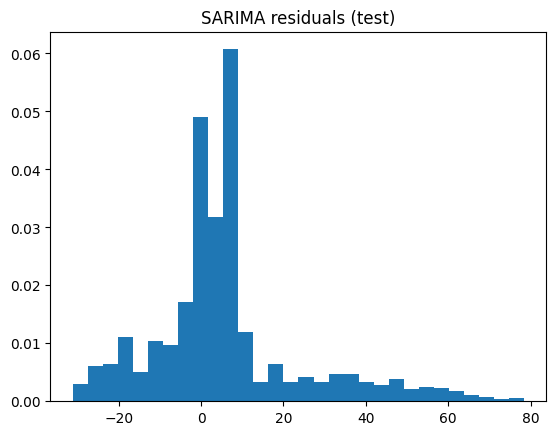

<Figure size 640x480 with 0 Axes>

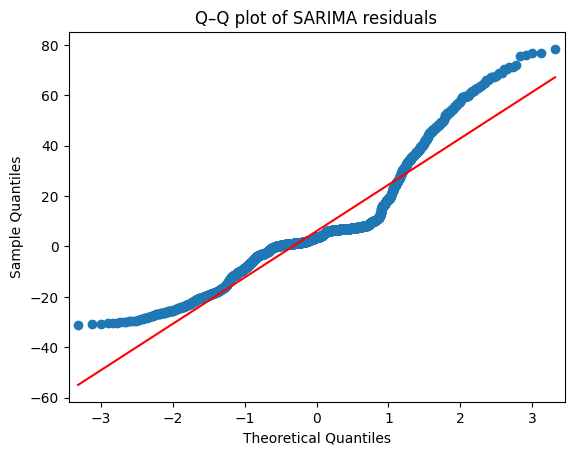

In [22]:

resid = sarima_test_df["residual"].dropna()
# Histogram
plt.figure()
plt.hist(resid, bins=30, density=True)
plt.title("SARIMA residuals (test)")
# Q-Q plot
plt.figure()
sm.qqplot(resid, line="s")
plt.title("Q–Q plot of SARIMA residuals")
sw_stat, sw_p = stats.shapiro(resid)
print("Shapiro–Wilk p-value:", sw_p)

In [23]:
pipeline_sarimax = {
    "model_type": "forecast",
    "preprocessing": [],  
    "splitter": splitter,
    "model": SARIMAX_Model,
    "hyperparams": {
        "order": [best_hp_sarima['order']],
        "seasonal_order": [best_hp_sarima['seasonal_order']],
        "exog_col": ["temperature"],   
        "target_col": ["elecmeter"],   
    },
}

In [24]:
results_SARIMAX, best_hp_sarimax, best_prep_sarimax2 = run_pipelines_hyperparam(df_elec_temp, [pipeline_sarimax], {"rmse":rmse,"mbe":mbe})


Running pipeline 1


In [25]:
results_SARIMAX.sort_values("rmse", ascending=True, inplace=True)
results_SARIMAX

,pipeline_idx,preprocessing,order,seasonal_order,exog_col,target_col,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,,"(0, 0, 1)","(0, 1, 1, 24)",temperature,elecmeter,15.431976,-0.646722,13.200002,11.05108,-0.301647


### **XgBoost Model**

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

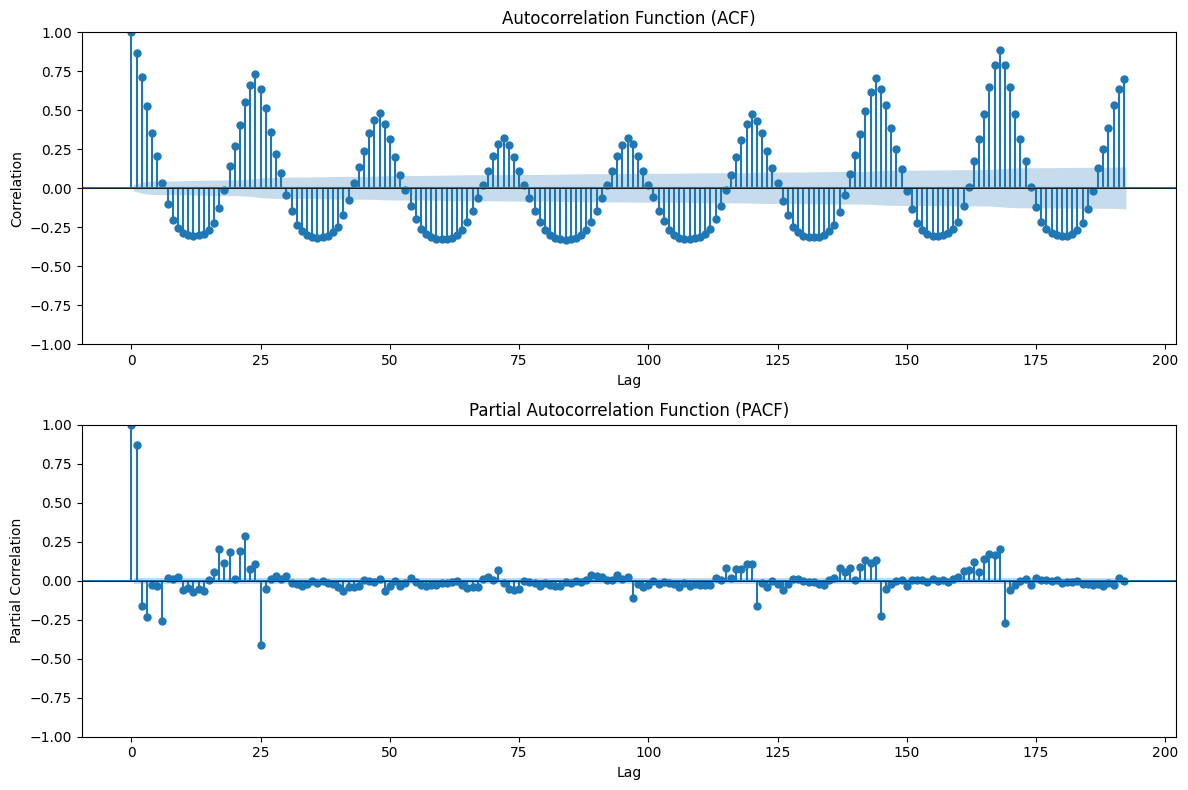

In [27]:
# Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# ACF plot
plot_acf(df_elec['elecmeter'], ax=ax1, lags=192, alpha=0.05)
ax1.set_title('Autocorrelation Function (ACF)')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Correlation')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# PACF plot
plot_pacf(df_elec['elecmeter'], ax=ax2, lags=192, alpha=0.05, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Partial Correlation')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

In [28]:
target_col = "elecmeter"
pipeline_1_xg = {"model_type": "tabular", 
"target_col": target_col,
"preprocessing": [Standardize(), 
                LagFeatures(target_col=target_col, lags=[1]), 
                CalendarFeatures(features=["hour", "dayofweek", "month"], cyclical=True),
                GermanHoliday(subdiv="SH")],
"splitter":splitter,
"model": lambda **kw: XGBModel(**kw), 
"hyperparams": {"n_estimators": [50, 100], "max_depth": [3, 6]}}

pipeline_2_xg = {"model_type": "tabular", 
"target_col": target_col,
"preprocessing": [LagFeatures(target_col=target_col, lags=[1])],
"splitter":splitter,
"model": lambda **kw: XGBModel(**kw), 
"hyperparams": {"n_estimators": [50, 100], "max_depth": [3, 6]}}

xgboost_pipelines = [pipeline_1_xg, pipeline_2_xg]

In [29]:
results_xgboost, best_hp_xgboost, best_prep_xgboost = run_pipelines_hyperparam(df_elec, xgboost_pipelines, {"rmse":rmse,"mbe":mbe})


Running pipeline 1

Running pipeline 2


In [30]:
results_xgboost.sort_values("rmse", ascending=True).head()

,pipeline_idx,preprocessing,n_estimators,max_depth,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,Standardize + LagFeatures + CalendarFeatures +...,100,3,6.001767,0.372047,0.056550,4.685929,-0.000263
1,1,Standardize + LagFeatures + CalendarFeatures +...,50,3,6.142756,0.518978,0.106832,5.088498,-0.000607
2,1,Standardize + LagFeatures + CalendarFeatures +...,50,6,6.325543,0.128681,0.040696,3.056585,-0.000321
3,1,Standardize + LagFeatures + CalendarFeatures +...,100,6,6.589977,0.159785,0.096724,2.309320,-0.001148
4,2,LagFeatures,50,3,11.095421,0.599855,0.027161,10.404021,-0.000213


In [31]:
format_for_csv(results_xgboost.head().drop("preprocessing",axis=1)).sort_values("rmse")

,pipeline_idx,n_estimators,max_depth,rmse,mbe,elapsed_sec,train_rmse,train_mbe
4,2,50,3,11.10,0.60,0.03,10.40,-0.00
0,1,100,3,6.00,0.37,0.06,4.69,-0.00
1,1,50,3,6.14,0.52,0.11,5.09,-0.00
2,1,50,6,6.33,0.13,0.04,3.06,-0.00
3,1,100,6,6.59,0.16,0.10,2.31,-0.00


In [32]:
if SAVE:
    format_for_csv(results_xgboost.head().drop("preprocessing",axis=1)).sort_values("rmse").to_csv(DATA_DIR/"electricity_xgboost_Summary.csv",index=False)

In [33]:
from copy import deepcopy
pipelines = []
for n in range(1, 15):  # n from 1 to 12
    pipeline = {
        "model_type": "tabular",
        "target_col": target_col,
        "preprocessing": [
            LagFeatures(target_col=target_col, lags=[1] + [12 * i for i in range(1, n+1)]),
            CalendarFeatures(features=["hour", "dayofweek", "month"], cyclical=True),
                GermanHoliday(subdiv="SH")
        ],
        "splitter": splitter,
        "model": lambda **kw: XGBModel(**kw),
        "hyperparams": {"n_estimators": [100], "max_depth": [3]}
    }
    
    pipelines.append(deepcopy(pipeline))

In [34]:
results_xgboost2, best_hp_xgboost2, best_prep_xgboost2 = run_pipelines_hyperparam(df_elec, pipelines, {"rmse":rmse,"mbe":mbe})


Running pipeline 1

Running pipeline 2

Running pipeline 3

Running pipeline 4

Running pipeline 5

Running pipeline 6

Running pipeline 7

Running pipeline 8

Running pipeline 9

Running pipeline 10

Running pipeline 11

Running pipeline 12

Running pipeline 13

Running pipeline 14


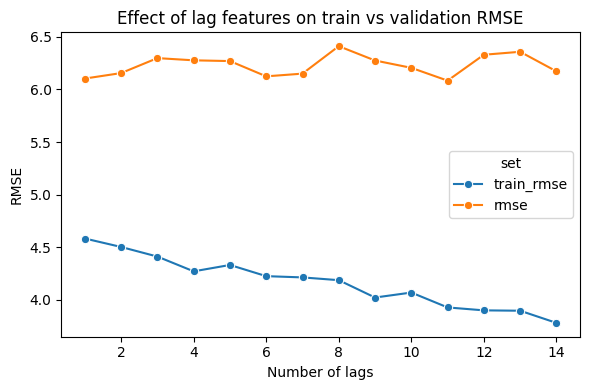

In [35]:
df = results_xgboost2.sort_values("pipeline_idx")
df["num_lags"] = df["pipeline_idx"].astype(int)
df_plot = df[["num_lags", "train_rmse", "rmse"]].sort_values("num_lags")
df_long = df_plot.melt(
    id_vars="num_lags",
    value_vars=["train_rmse", "rmse"],
    var_name="set",
    value_name="RMSE",
)
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=df_long,
    x="num_lags",
    y="RMSE",
    hue="set",
    marker="o",
)
plt.xlabel("Number of lags")
plt.ylabel("RMSE")
plt.title("Effect of lag features on train vs validation RMSE")
plt.tight_layout()
plt.show()

### **LSTM Model**

In [36]:
preprocessors_lstm_e = [Standardize(), 
                LagFeatures(target_col=target_col, lags=[1, 2, 3, 24, 168]), 
                CalendarFeatures(features=["hour", "dayofweek", "month"], cyclical=True), 
                ReshapeToSequence(target_col=target_col, seq_len=24)]

def lstm_factory_elec(**kwargs):
    df_p = df_elec.copy()  # must be DataFrame so LagFeatures uses column 'elecmeter', not index
    for p in preprocessors_lstm_e:
        p.fit(df_p)
        df_p = p.transform(df_p)
    if isinstance(df_p, tuple):
        X, y = df_p
        return LSTM_Model(input_size=X.shape[2], **kwargs)
    return LSTM_Model(input_size=df_p.shape[1], **kwargs)

# pipeline_1_lstm = {"model_type": "tensor", 
#         "target_col": target_col,
#         "preprocessing": preprocessors_lstm_e, 
#         "splitter": TimeSeriesSplitter().transform,
#          "model": lstm_factory_elec, 
#          "hyperparams": {"hidden_size": [16, (16, 32), (16, 32, 12)], "epochs": [50,100], "patience": [5,15], "dropout": [0.1]}}

pipeline_1_lstm = {"model_type": "tensor", 
        "target_col": target_col,
        "preprocessing": preprocessors_lstm_e, 
        "splitter": splitter,
         "model": lstm_factory_elec, 
         "hyperparams": {"hidden_size": [16, 32],"num_layers":[2,4], "epochs": [50,100], "patience": [5,15], "dropout": [0.1],"lr":[0.001]}}



In [37]:
results_LSTM, best_hp_lstm, best_prep_lstm = run_pipelines_hyperparam(df_elec, [pipeline_1_lstm], {"rmse":rmse,"mbe":mbe})


Running pipeline 1


In [38]:
results_LSTM.sort_values("rmse", ascending=True).head()

,pipeline_idx,preprocessing,hidden_size,num_layers,epochs,patience,dropout,lr,rmse,mbe,elapsed_sec,train_rmse,train_mbe,history
0,1,Standardize + LagFeatures + CalendarFeatures +...,32,2,50,5,0.1,0.001,7.404335,-0.168698,4.347251,6.352854,-0.681327,"{'train_loss': [0.6277608892092338, 0.20983003..."
1,1,Standardize + LagFeatures + CalendarFeatures +...,16,2,100,5,0.1,0.001,7.449715,0.952049,4.590300,6.718585,-0.183211,"{'train_loss': [0.8938710570335389, 0.40155384..."
2,1,Standardize + LagFeatures + CalendarFeatures +...,32,2,100,15,0.1,0.001,7.487879,0.028232,9.173421,5.589902,0.238253,"{'train_loss': [0.6050324456049846, 0.22133696..."
3,1,Standardize + LagFeatures + CalendarFeatures +...,16,4,50,15,0.1,0.001,7.507227,0.971725,17.586357,5.944561,-0.189458,"{'train_loss': [0.8392926289485051, 0.27536736..."
4,1,Standardize + LagFeatures + CalendarFeatures +...,16,4,100,5,0.1,0.001,7.584423,1.161573,5.920057,7.370769,0.054292,"{'train_loss': [0.9078503755422739, 0.27393230..."


In [39]:
format_for_csv(results_LSTM.head().drop(["preprocessing","history"],axis=1),decimal_places=3).sort_values("rmse")

,pipeline_idx,hidden_size,num_layers,epochs,patience,dropout,lr,rmse,mbe,elapsed_sec,train_rmse,train_mbe
0,1,32,2,50,5,0.100,0.001,7.404,-0.169,4.347,6.353,-0.681
1,1,16,2,100,5,0.100,0.001,7.450,0.952,4.590,6.719,-0.183
2,1,32,2,100,15,0.100,0.001,7.488,0.028,9.173,5.590,0.238
3,1,16,4,50,15,0.100,0.001,7.507,0.972,17.586,5.945,-0.189
4,1,16,4,100,5,0.100,0.001,7.584,1.162,5.920,7.371,0.054


In [40]:
if SAVE:
    format_for_csv(results_LSTM.head().drop(["preprocessing","history"],axis=1),decimal_places=3).sort_values("rmse").to_csv(DATA_DIR/"electricity_lstm_Summary.csv",index=False)

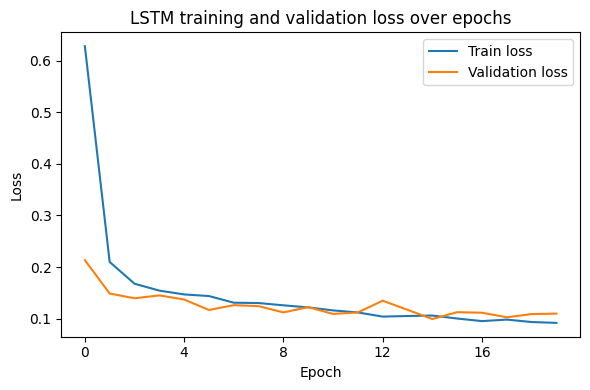

In [41]:
df_lstm = pd.DataFrame(results_LSTM.sort_values("rmse", ascending=True).history[0])
plt.figure(figsize=(6, 4))
plt.plot(df_lstm.index, df_lstm["train_loss"], label="Train loss")
plt.plot(df_lstm.index, df_lstm["val_loss"],   label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM training and validation loss over epochs")
plt.legend()
# Force integer epoch ticks
epochs = df_lstm.index.to_numpy()
plt.xticks(np.arange(0, len(df_lstm), 4))  # or np.arange(len(df_lstm)) if you prefer
plt.tight_layout()
plt.show()

In [42]:
df_lstm.index

RangeIndex(start=0, stop=20, step=1)

### Compare all models on test set

Use the best hyperparameters from validation to evaluate each model once on the **test set** (RMSE and MAPE).

In [33]:
# One entry per model: (name, data, pipelines_list, results_df, best_hyperparameters)
test_configs = [
    ("Persistence", df_elec, pipelines_persistence, results_persistence, best_hp_persistence),
    ("SARIMA", series_elec, sarima_piplines, results_SARIMA, best_hp_sarima),
    ("XGBoost", df_elec, xgboost_pipelines, results_xgboost, best_hp_xgboost),
    ("LSTM", df_elec, [pipeline_1_lstm], results_LSTM, best_hp_lstm),
]
test_metrics = {"rmse": rmse, "mbe": mbe}
comparison_test = compare_models_on_test(test_configs, metric_fn=test_metrics)
comparison_test

,model,rmse,mbe,elapsed_sec,train_rmse,train_mbe,history
0,Persistence,25.033803,-11.874539,0.000297,11.446296,0.000849,NaN
1,SARIMA,18.398658,-1.902672,8.167632,11.055447,-0.070799,NaN
2,XGBoost,5.882262,-1.385532,0.053149,4.685929,-0.000263,NaN
3,LSTM,9.826471,-2.109478,4.720110,6.227643,0.130137,"{'train_loss': [0.6373826673397651, 0.20990187..."


In [34]:
def format_for_csv(df, decimal_places=2):
    out = df.copy()
    for col in out.select_dtypes(include=["number"]).columns:
        if out[col].dtype in ("int64", "int32"):
            out[col] = out[col].apply(lambda x: f"{int(x):,}")
        else:
            out[col] = out[col].apply(lambda x: f"{x:,.{decimal_places}f}")
    return out

In [ ]:
if SAVE:
    format_for_csv(comparison_test.drop(["history"],axis=1).sort_values("rmse")).to_csv(DATA_DIR/"electricity_forecast_summary.csv",index=False)

In [36]:
comparison_test

,model,rmse,mbe,elapsed_sec,train_rmse,train_mbe,history
0,Persistence,25.033803,-11.874539,0.000297,11.446296,0.000849,NaN
1,SARIMA,18.398658,-1.902672,8.167632,11.055447,-0.070799,NaN
2,XGBoost,5.882262,-1.385532,0.053149,4.685929,-0.000263,NaN
3,LSTM,9.826471,-2.109478,4.720110,6.227643,0.130137,"{'train_loss': [0.6373826673397651, 0.20990187..."


In [ ]:
if SAVE:
    # Best model's test forecast (for optimizers)
    best_name, forecast_df = best_model_test_forecast(
        test_configs, comparison_test, primary_metric="rmse"
    )
    print(f"Best model: {best_name}")

    # Save forecast to CSV (only forecast column for optimizers; keep actual for reference if you want)
    forecast_df.to_csv(ROOT / "Data" / "pv_forecast_test.csv")
    # Or only the forecast column:
    forecast_df.to_csv(ROOT / "Data" / "electricity_forecast_for_optimizer.csv")